# Effective Rank — Feasibility Test v0.1

**Objetivo:** testar se o *Effective Rank* (ER) mede de forma coerente a dimensionalidade do mercado antes de construir qualquer estratégia.

Este notebook **não otimiza Sharpe, CAGR ou parâmetros**. Ele é um teste inicial de falsificação.

## Research question
> A dimensionalidade efetiva do mercado contém informação estável sobre o *opportunity set* cross-sectional?

## Hipóteses congeladas nesta etapa
- **H1 — Validade estrutural:** ER baixo deve estar associado a maior concentração do movimento do mercado em poucos componentes.
- **H2 — Coerência econômica:** ER deve variar de forma consistente com correlação média e domínio do primeiro componente.
- **H3 — Estabilidade:** a relação deve aparecer em diferentes janelas razoáveis, sem depender de um único período extremo.

> A hipótese de alpha será adicionada somente após aprovação explícita da escolha do alpha-base.

## Universo inicial de feasibility
ETFs setoriais americanos líquidos e com histórico longo:

`XLB, XLE, XLF, XLI, XLK, XLP, XLU, XLV, XLY`

Esta escolha é **apenas para feasibility**; não implica que o modelo final usará ETFs ou mercado americano.

## 0. Regras metodológicas pré-definidas

1. Somente informação disponível até a data \(t\) pode entrar no cálculo de \(ER_t\).
2. Nenhum parâmetro será escolhido com base em performance futura.
3. A janela-base será **252 pregões**.
4. Janelas de robustez, se necessárias, serão apenas **126 e 504 pregões**.
5. O cálculo será feito com retornos diários e a análise estrutural será mensal.
6. Preços serão ajustados por proventos/splits via `auto_adjust=True`.
7. Os dados baixados serão armazenados localmente para reprodutibilidade.

In [8]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import yfinance as yf
except ImportError as exc:
    raise ImportError(
        "Instale yfinance antes de rodar este notebook: pip install yfinance"
    ) from exc

DATA_DIR = Path("../data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

TICKERS = ["XLB", "XLE", "XLF", "XLI", "XLK", "XLP", "XLU", "XLV", "XLY"]
START = "2000-01-01"
END = None

WINDOW = 252
MIN_COVERAGE = 0.98
CACHE_FILE = DATA_DIR / "us_sector_etfs_adjusted_close.csv"

TICKERS

['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']

## 1. Coleta e cache dos dados

O notebook tenta reutilizar um CSV local antes de acessar a internet. Isso permite repetir exatamente a mesma análise posteriormente.

In [9]:
def load_prices(force_download: bool = False) -> pd.DataFrame:
    if CACHE_FILE.exists() and not force_download:
        return pd.read_csv(CACHE_FILE, index_col=0, parse_dates=True).sort_index()

    raw = yf.download(
        TICKERS,
        start=START,
        end=END,
        auto_adjust=True,
        progress=False,
        group_by="column",
        threads=True,
    )

    if raw.empty:
        raise RuntimeError("Download retornou vazio.")

    if isinstance(raw.columns, pd.MultiIndex):
        if "Close" in raw.columns.get_level_values(0):
            prices = raw["Close"].copy()
        elif "Close" in raw.columns.get_level_values(1):
            prices = raw.xs("Close", axis=1, level=1).copy()
        else:
            raise KeyError("Coluna Close não encontrada.")
    else:
        prices = raw[["Close"]].rename(columns={"Close": TICKERS[0]})

    prices = prices.reindex(columns=TICKERS).sort_index()
    prices.to_csv(CACHE_FILE)
    return prices

prices = load_prices()
prices.tail()

Ticker,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
Date,,,,,,,,,
2026-08-04,52.000000,58.520000,57.880001,186.399994,186.899994,85.370003,44.110001,162.100006,118.290001
2026-08-05,52.639999,57.310001,58.000000,186.350006,185.910004,85.330002,43.660000,164.160004,118.639999
2026-08-06,52.169998,58.160000,57.810001,184.759995,185.330002,85.110001,43.380001,164.449997,118.099998
2026-08-07,52.860001,57.500000,57.599998,185.179993,187.970001,85.120003,43.610001,165.679993,119.860001
2026-08-10,53.180000,60.180000,57.810001,184.600006,186.320007,84.949997,43.130001,168.440002,119.669998


## 2. Auditoria mínima de qualidade

Não fazemos *backfill*. Pequenos buracos isolados podem ser preenchidos com o último preço conhecido, mas períodos longos incompletos são descartados.

In [10]:
coverage = prices.notna().mean().sort_values()
display(coverage.to_frame("coverage"))

first_valid_dates = prices.apply(pd.Series.first_valid_index)
common_start = max(first_valid_dates)

px = prices.loc[common_start:].copy()
daily_coverage = px.notna().mean(axis=1)
px = px.loc[daily_coverage >= MIN_COVERAGE]
px = px.ffill(limit=3)
px = px.dropna(how="any")

print("Common start:", common_start)
print("Observações:", len(px))
print("Início:", px.index.min())
print("Fim:", px.index.max())

assert not px.empty
assert not px.isna().any().any()

,coverage
Ticker,
XLB,1.0
XLE,1.0
XLF,1.0
XLI,1.0
XLK,1.0
XLP,1.0
XLU,1.0
XLV,1.0
XLY,1.0


Common start: 2000-01-03 00:00:00
Observações: 6690
Início: 2000-01-03 00:00:00
Fim: 2026-08-10 00:00:00


## 3. Retornos

Usamos retornos logarítmicos diários:

\[
r_{i,t} = \ln(P_{i,t}/P_{i,t-1})
\]

In [11]:
returns = np.log(px / px.shift(1)).dropna()
returns.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
Ticker,,,,
XLB,0.000299,0.014864,-0.132527,0.131534
XLE,0.000330,0.018204,-0.224910,0.152503
XLF,0.000247,0.017813,-0.182321,0.152394
XLI,0.000348,0.013367,-0.120408,0.119126
XLK,0.000329,0.016307,-0.148662,0.149296
XLP,0.000292,0.009433,-0.098668,0.081678
XLU,0.000308,0.012106,-0.120561,0.120388
XLV,0.000316,0.011207,-0.103817,0.113816
XLY,0.000355,0.014315,-0.135461,0.103351


## 4. Definição do Effective Rank

Para uma matriz de correlação \(C_t\), com autovalores \(\lambda_1,\ldots,\lambda_N\):

\[
ER_t =
\frac{\left(\sum_i \lambda_i\right)^2}
{\sum_i \lambda_i^2}
\]

Também calculamos:

\[
MarketMode_t =
\frac{\lambda_{1,t}}{\sum_i \lambda_{i,t}}
\]

e a correlação média entre pares de ativos.

In [12]:
def effective_rank_from_corr(corr: np.ndarray) -> tuple[float, float]:
    eigvals = np.linalg.eigvalsh(corr)
    eigvals = np.clip(eigvals, 0.0, None)
    eigvals = np.sort(eigvals)[::-1]

    total = eigvals.sum()
    if total <= 0:
        return np.nan, np.nan

    er = (total ** 2) / np.square(eigvals).sum()
    market_mode = eigvals[0] / total
    return float(er), float(market_mode)


def mean_pairwise_corr(corr: np.ndarray) -> float:
    upper = corr[np.triu_indices(corr.shape[0], k=1)]
    return float(np.nanmean(upper))


def rolling_structure(rets: pd.DataFrame, window: int = 252) -> pd.DataFrame:
    rows = []

    for end in range(window, len(rets) + 1):
        window_rets = rets.iloc[end - window:end]
        corr = window_rets.corr().to_numpy()

        er, market_mode = effective_rank_from_corr(corr)

        rows.append({
            "date": rets.index[end - 1],
            "effective_rank": er,
            "market_mode": market_mode,
            "mean_corr": mean_pairwise_corr(corr),
        })

    return pd.DataFrame(rows).set_index("date")

structure_daily = rolling_structure(returns, WINDOW)
structure_daily.tail()

,effective_rank,market_mode,mean_corr
date,,,
2026-08-04,4.806795,0.364539,0.220243
2026-08-05,4.837399,0.362024,0.217297
2026-08-06,4.829381,0.362537,0.217250
2026-08-07,4.801365,0.364241,0.218682
2026-08-10,4.803874,0.364185,0.218878


## 5. Frequência mensal da análise estrutural

O ER é estimado diariamente com uma janela *rolling*, mas avaliamos sua informação usando apenas a última observação disponível de cada mês.

In [13]:
structure_monthly = structure_daily.resample("ME").last().dropna()
structure_monthly.tail()

,effective_rank,market_mode,mean_corr
date,,,
2026-04-30,4.112023,0.430303,0.316612
2026-05-31,4.424012,0.406095,0.278013
2026-06-30,4.671095,0.381052,0.245629
2026-07-31,4.804108,0.364479,0.222831
2026-08-31,4.803874,0.364185,0.218878


# TESTE H1 — ER mede concentração estrutural?

Esperamos:

\[
ER \downarrow \Rightarrow MarketMode \uparrow
\]

e, em geral:

\[
ER \downarrow \Rightarrow CorrMedia \uparrow
\]

In [14]:
corr_summary = structure_monthly[
    ["effective_rank", "market_mode", "mean_corr"]
].corr()

corr_summary

,effective_rank,market_mode,mean_corr
effective_rank,1.000000,-0.969422,-0.971046
market_mode,-0.969422,1.000000,0.998246
mean_corr,-0.971046,0.998246,1.000000


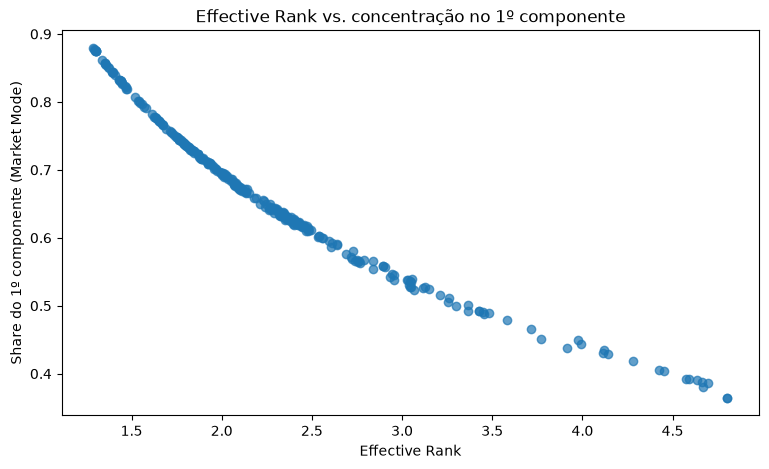

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(
    structure_monthly["effective_rank"],
    structure_monthly["market_mode"],
    alpha=0.7,
)
ax.set_xlabel("Effective Rank")
ax.set_ylabel("Share do 1º componente (Market Mode)")
ax.set_title("Effective Rank vs. concentração no 1º componente")
plt.show()

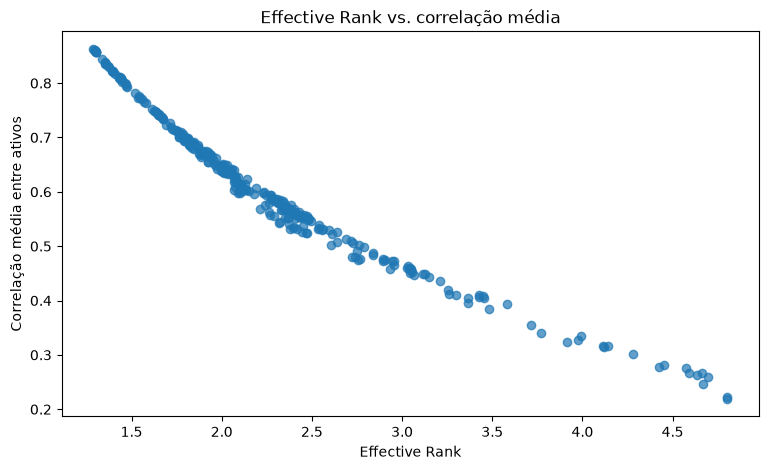

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(
    structure_monthly["effective_rank"],
    structure_monthly["mean_corr"],
    alpha=0.7,
)
ax.set_xlabel("Effective Rank")
ax.set_ylabel("Correlação média entre ativos")
ax.set_title("Effective Rank vs. correlação média")
plt.show()

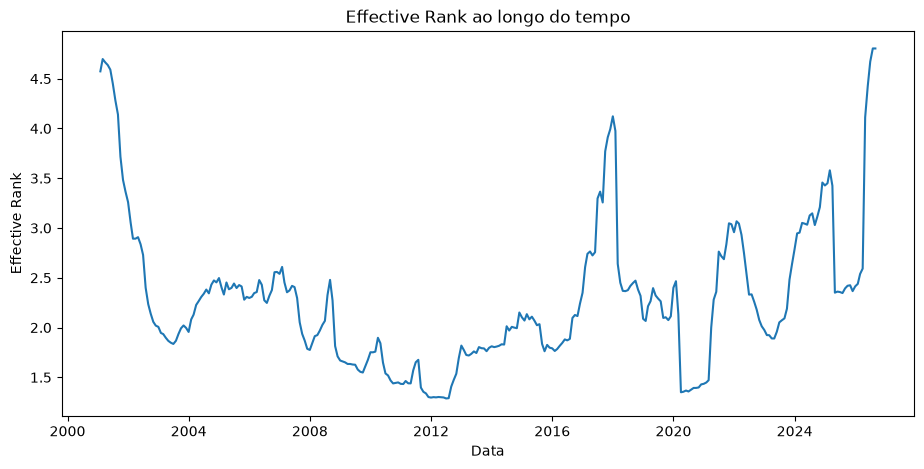

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(structure_monthly.index, structure_monthly["effective_rank"])
ax.set_xlabel("Data")
ax.set_ylabel("Effective Rank")
ax.set_title("Effective Rank ao longo do tempo")
plt.show()

## 6. Validação por quintis do próprio estado estrutural

Ainda **não testamos retorno**. Queremos apenas verificar se extremos de ER correspondem a ambientes estruturalmente diferentes.

In [18]:
tmp = structure_monthly.copy()
tmp["er_quintile"] = pd.qcut(
    tmp["effective_rank"],
    q=5,
    labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
    duplicates="drop",
)

structural_by_q = (
    tmp.groupby("er_quintile", observed=True)
       .agg(
           n=("effective_rank", "size"),
           er_mean=("effective_rank", "mean"),
           mean_corr=("mean_corr", "mean"),
           market_mode=("market_mode", "mean"),
       )
)

structural_by_q

,n,er_mean,mean_corr,market_mode
er_quintile,,,,
Q1,62,1.498083,0.790391,0.815588
Q2,61,1.869094,0.678560,0.721958
Q3,62,2.169384,0.602128,0.662434
Q4,61,2.434916,0.551144,0.618693
Q5,62,3.440284,0.403840,0.497027


## 7. Critério preliminar de GO / NO-GO para H1

**GO estrutural** se:
1. ER e `market_mode` tiverem relação negativa forte e estável;
2. ER e `mean_corr` tiverem relação econômica coerente;
3. os quintis mostrarem separação estrutural clara;
4. a série não for dominada por erros de dados ou poucos pontos extremos.

**NO-GO estrutural** se ER não distinguir de maneira clara ambientes de alta vs. baixa concentração.

Nenhum threshold automático será escolhido nesta etapa.

In [19]:
def structural_diagnostics(structure: pd.DataFrame) -> pd.Series:
    return pd.Series({
        "corr_ER_market_mode": structure["effective_rank"].corr(structure["market_mode"]),
        "corr_ER_mean_corr": structure["effective_rank"].corr(structure["mean_corr"]),
        "ER_mean": structure["effective_rank"].mean(),
        "ER_std": structure["effective_rank"].std(),
        "ER_min": structure["effective_rank"].min(),
        "ER_max": structure["effective_rank"].max(),
        "n_months": len(structure),
    })

diagnostics = structural_diagnostics(structure_monthly)
diagnostics

corr_ER_market_mode     -0.969422
corr_ER_mean_corr       -0.971046
ER_mean                  2.283199
ER_std                   0.729603
ER_min                   1.287975
ER_max                   4.804108
n_months               308.000000
dtype: float64

# PONTO DE DECISÃO — Alpha-base

**Pare aqui antes de construir qualquer sinal de retorno.**

### Opção A — Residual Momentum
Testa persistência de movimentos específicos após remover o componente comum.

**Prós:** casa diretamente com a hipótese de dimensionalidade e reduz beta comum.  
**Contras:** adiciona uma camada estatística.

### Opção B — Momentum cross-sectional simples
Rankeia os ETFs pelo retorno passado.

**Prós:** máxima transparência e ótimo benchmark.  
**Contras:** parte do sinal pode ser apenas movimento comum do mercado.

### Minha recomendação provisória
Usar **B apenas como baseline de controle** e **A como alpha principal**, caso você aprove essa lógica.

O restante do notebook deve ser completado somente depois dessa decisão.

## Registro de decisões

| Item | Decisão |
|---|---|
| Universo inicial | ETFs setoriais EUA |
| Frequência dos dados | diária |
| Frequência da análise estrutural | mensal |
| Janela ER baseline | 252 pregões |
| Métrica ER | participation-ratio effective rank |
| Alpha-base | **PENDENTE** |
| OOS | **a definir antes do primeiro teste de alpha** |
| Estratégia de alocação | **não definida nesta fase** |